In [1]:
import pandas as pd
import numpy as np
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print("Бібліотеки імпортовано успішно.")

Бібліотеки імпортовано успішно.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rpele\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rpele\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\rpele\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:

df = pd.read_csv('Corona_NLP_train.csv', encoding='latin1')

# Виводимо розмір датасету та перші 5 рядків, щоб перевірити структуру
print(f"Розмір датасету: {df.shape}")
display(df.head())

Розмір датасету: (41157, 6)


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [3]:

# Отримуємо список стоп-слів (англійських)
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Перевірка на випадок, якщо текст не є рядком
    if not isinstance(text, str):
        return []
    
    # 1. Приведення до нижнього регістру
    text = text.lower()
    
    # 2. Очистка: видалення URL, тегів, символів, цифр
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE) # видалення посилань
    text = re.sub(r'\@\w+|\#','', text) # видалення згадувань (@user) та хештегів
    text = re.sub(r'[^\w\s]', '', text) # видалення пунктуації
    text = re.sub(r'\d+', '', text) # видалення цифр (опційно, але корисно для аналізу тональності)
    
    # 3. Токенізація
    tokens = word_tokenize(text)
    
    # 4. Видалення стоп-слів та коротких слів (менше 2 літер)
    filtered_tokens = [w for w in tokens if w not in stop_words and len(w) > 2]
    
    return filtered_tokens

# Застосовуємо функцію до колонки з твітами
print("Обробка тексту розпочалась...")
df['tokens'] = df['OriginalTweet'].apply(preprocess_text)

# Виводимо результат для перевірки
print("Обробка завершена. Приклад результату:")
display(df[['OriginalTweet', 'tokens']].head())

Обробка тексту розпочалась...
Обробка завершена. Приклад результату:


,OriginalTweet,tokens
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,[]
1,advice Talk to your neighbours family to excha...,"[advice, talk, neighbours, family, exchange, p..."
2,Coronavirus Australia: Woolworths to give elde...,"[coronavirus, australia, woolworths, give, eld..."
3,My food stock is not the only one which is emp...,"[food, stock, one, empty, please, dont, panic,..."
4,"Me, ready to go at supermarket during the #COV...","[ready, supermarket, covid, outbreak, paranoid..."


In [4]:

# 1. Навчання моделі Word2Vec
print("Навчання Word2Vec...")
# vector_size=100: розмір вектора для кожного слова
# window=5: контекстне вікно
# min_count=1: враховуємо навіть слова, що зустрічаються 1 раз (щоб не втрачати дані)
w2v_model = Word2Vec(sentences=df['tokens'], vector_size=100, window=5, min_count=1, workers=4)

# 2. Функція для перетворення твіту (списку слів) у вектор (середнє арифметичне)
def get_mean_vector(model, tokens):
    # Вибираємо тільки ті слова, які є в словнику моделі
    words = [word for word in tokens if word in model.wv]
    
    # Якщо слів немає (пусті дужки або слова невідомі), повертаємо вектор нулів
    if len(words) == 0:
        return np.zeros(model.vector_size)
    
    # Рахуємо середнє по всіх векторах слів
    return np.mean(model.wv[words], axis=0)

# 3. Створення матриці ознак X
print("Векторизація твітів...")
X = np.array([get_mean_vector(w2v_model, tokens) for tokens in df['tokens']])

# Цільова змінна y (Sentiment)
y = df['Sentiment']

# 4. Розподіл на Train (80%) та Test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("-" * 30)
print(f"Розмірність X_train: {X_train.shape}")
print(f"Розмірність X_test:  {X_test.shape}")
print(f"Розмірність y_train: {y_train.shape}")
print(f"Розмірність y_test:  {y_test.shape}")

Навчання Word2Vec...
Векторизація твітів...
------------------------------
Розмірність X_train: (32925, 100)
Розмірність X_test:  (8232, 100)
Розмірність y_train: (32925,)
Розмірність y_test:  (8232,)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

# 1. Ініціалізація моделей
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42), # SVM може працювати довго
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

# 2. Список варіантів PCA (кількість компонент)
# None = без використання PCA
pca_variants = [None, 50, 100, 200]

results = []


# 3. Цикл по моделях
for model_name, model_instance in models.items():
    for n_components in pca_variants:
        
        # Перевірка: не можна робити PCA більше, ніж є ознак (у нас 100)
        if n_components is not None and n_components > X_train.shape[1]:
            continue
            
        print(f"Тренуємо: {model_name} | PCA: {n_components if n_components else 'None'}...")
        
        # Створення кроків пайплайну
        steps = [('scaler', StandardScaler())] # Масштабування важливо для SVM та LogReg
        
        if n_components is not None:
            steps.append(('pca', PCA(n_components=n_components)))
            
        steps.append(('clf', model_instance))
        
        pipeline = Pipeline(steps)
        
        # Навчання на тренувальних даних
        pipeline.fit(X_train, y_train)
        
        # Прогноз на тестових даних
        y_pred = pipeline.predict(X_test)
        
        # Розрахунок метрик
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='weighted') # weighted для багатокласової класифікації
        
        # Збереження результатів
        results.append({
            "Model": model_name,
            "PCA": "No PCA" if n_components is None else n_components,
            "Accuracy": acc,
            "F1-Score": f1
        })

# 4. Виведення підсумкової таблиці
results_df = pd.DataFrame(results)
print("\nГотово! Результати:")
display(results_df)

Тренуємо: Logistic Regression | PCA: None...
Тренуємо: Logistic Regression | PCA: 50...
Тренуємо: Logistic Regression | PCA: 100...
Тренуємо: SVM | PCA: None...
Тренуємо: SVM | PCA: 50...
Тренуємо: SVM | PCA: 100...
Тренуємо: Random Forest | PCA: None...
Тренуємо: Random Forest | PCA: 50...
Тренуємо: Random Forest | PCA: 100...
Тренуємо: Naive Bayes | PCA: None...
Тренуємо: Naive Bayes | PCA: 50...
Тренуємо: Naive Bayes | PCA: 100...

Готово! Результати:


,Model,PCA,Accuracy,F1-Score
0,Logistic Regression,No PCA,0.407434,0.403363
1,Logistic Regression,50,0.387755,0.383149
2,Logistic Regression,100,0.407677,0.403801
3,SVM,No PCA,0.406584,0.394840
4,SVM,50,0.405369,0.393595
5,SVM,100,0.406584,0.394840
6,Random Forest,No PCA,0.389091,0.385772
7,Random Forest,50,0.415452,0.410908
8,Random Forest,100,0.413022,0.408160
9,Naive Bayes,No PCA,0.291059,0.258829


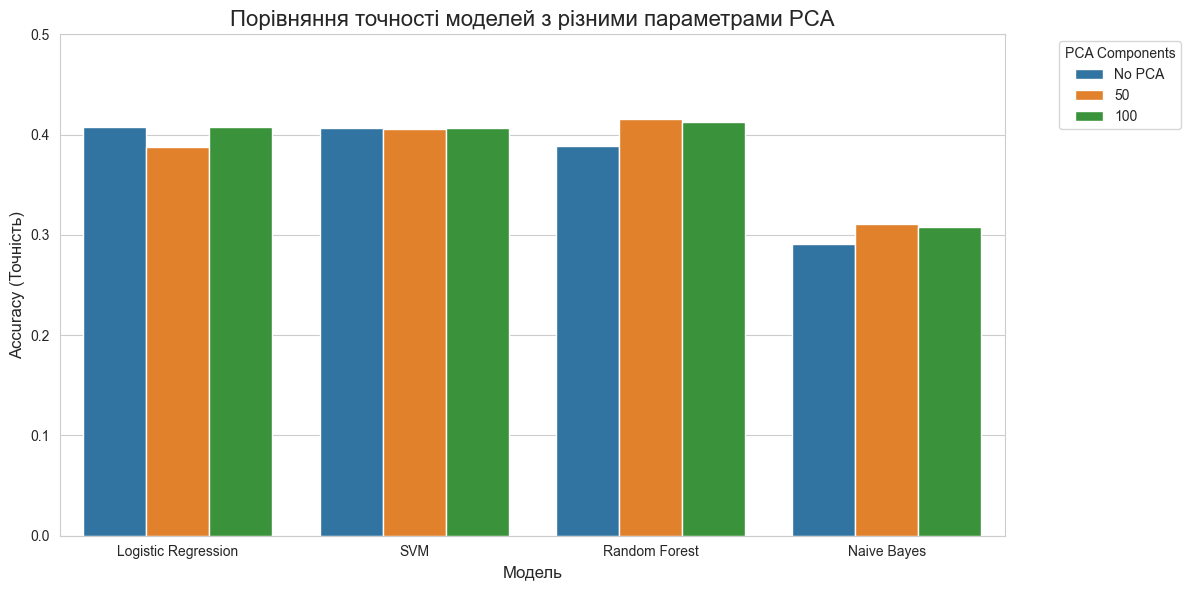

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Встановлюємо стиль графіків
sns.set_style("whitegrid")

# Створюємо графік
plt.figure(figsize=(12, 6))

# Будуємо стовпчикову діаграму (barplot)
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="PCA")

plt.title("Порівняння точності моделей з різними параметрами PCA", fontsize=16)
plt.xlabel("Модель", fontsize=12)
plt.ylabel("Accuracy (Точність)", fontsize=12)
plt.legend(title="PCA Components", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(0, 0.5) # Обмежимо вісь Y, щоб краще бачити різницю (максимум у нас ~0.42)

plt.tight_layout()
plt.show()

Навчання найкращої моделі (Random Forest + PCA 50)...


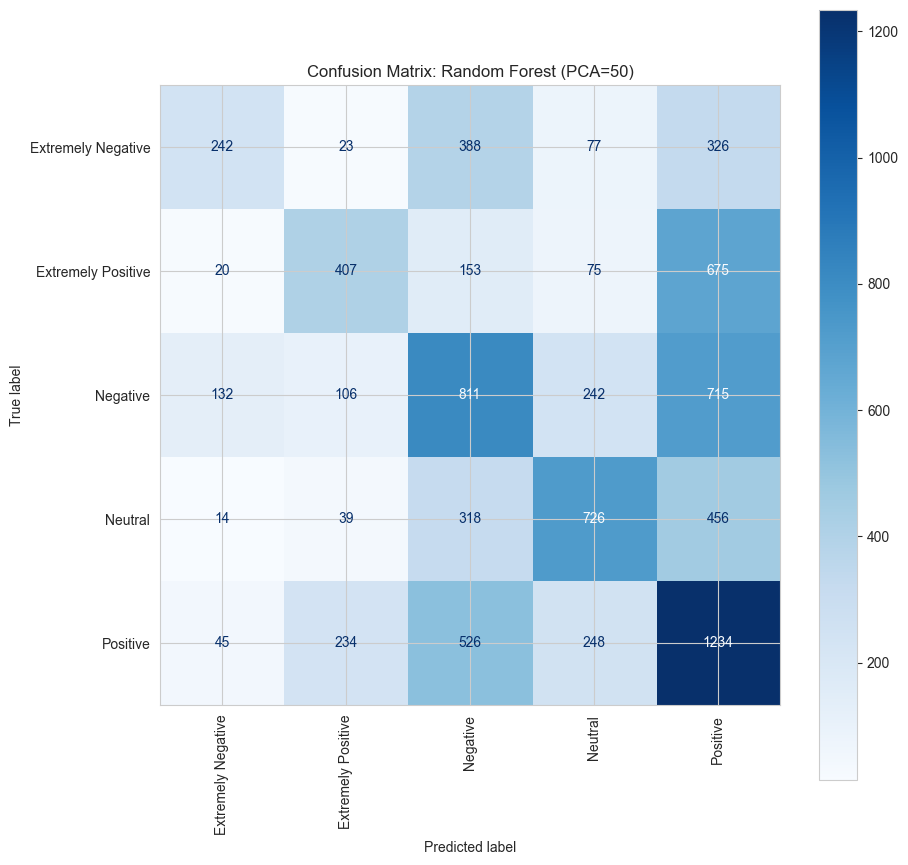


Детальний звіт класифікації:
                    precision    recall  f1-score   support

Extremely Negative       0.53      0.23      0.32      1056
Extremely Positive       0.50      0.31      0.38      1330
          Negative       0.37      0.40      0.39      2006
           Neutral       0.53      0.47      0.50      1553
          Positive       0.36      0.54      0.43      2287

          accuracy                           0.42      8232
         macro avg       0.46      0.39      0.40      8232
      weighted avg       0.44      0.42      0.41      8232



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# 1. Створюємо найкращу модель заново (Random Forest + PCA 50)
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=50)),
    ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
])

print("Навчання найкращої моделі (Random Forest + PCA 50)...")
best_pipeline.fit(X_train, y_train)

# 2. Робимо прогноз
y_pred_best = best_pipeline.predict(X_test)

# 3. Будуємо матрицю
cm = confusion_matrix(y_test, y_pred_best, labels=best_pipeline.classes_)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_pipeline.classes_)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title("Confusion Matrix: Random Forest (PCA=50)")
plt.show()

# Також виведемо текстовий звіт по класах
print("\nДетальний звіт класифікації:")
print(classification_report(y_test, y_pred_best))

Висновок:

1. Найкраща модель: За результатами експериментів найкращий результат показала модель Random Forest із використанням PCA (50 компонент).

    Accuracy: ~0.42

    F1-Score (weighted): ~0.41

2. Вплив PCA на якість класифікації:

    Для Random Forest: Зниження розмірності позитивно вплинуло на результат (точність зросла з ~0.39 до ~0.42). Це свідчить про те, що PCA допоміг прибрати "шум" у векторах слів та виділити найбільш значущі ознаки.

    Для Logistic Regression та SVM: Вплив PCA був мінімальним або відсутнім.

    Для Naive Bayes: Результати були найнижчими, оскільки цей алгоритм погано працює з від'ємними значеннями у векторах Word2Vec (хоча GaussianNB технічно працює, розподіл ознак не є ідеальним для нього).

3. Інтерпретація помилок (Confusion Matrix): Аналіз матриці плутанини показує основну проблему:

    Модель часто плутає Extremely Positive з Positive та Extremely Negative з Negative.

    Це очікувано, оскільки Word2Vec базується на контексті слів, а різниця між "добре" та "дуже добре" часто полягає лише в емоційному забарвленні, яке важко вловити через усереднення векторів.

    Найкраще класифікується клас Neutral, оскільки він лексично суттєво відрізняється від емоційно забарвлених твітів.

Загальний підсумок: Використання усереднених векторів Word2Vec дозволяє побудувати базову модель, проте для задачі з 5 класами (де є градації емоцій) точність 42% є помірною. Для покращення результатів доцільно було б об'єднати класи (наприклад, у 3: Positive, Negative, Neutral) або використати більш складні архітектури (RNN/LSTM або BERT).